In [21]:
import numpy as np
import scipy.io
from pathlib import Path
# from kilosort.io import load_ops

# Define Path and Load Files
results_dir = Path('D:\\Neural-Pipeline\\data\\20251211\\kilosort4')
APtimestamps = np.load(r"D:\Neural-Pipeline\data\20251211\zarya20251211dots3DMP_APtimestamps.npy")
save_path = 'D:\\Neural-Pipeline\\data\\20251211\\zarya_20251211_unit.mat'

spike_clusters = np.load(results_dir / 'spike_clusters.npy')
spike_times = np.load(results_dir / 'spike_times.npy')
spike_detection_templates = np.load(results_dir / 'spike_detection_templates.npy')
templates_ind = np.load(results_dir / 'templates_ind.npy')
channel_positions = np.load(results_dir / 'channel_positions.npy')
amplitudes = np.load(results_dir / 'amplitudes.npy')
channel_map =  np.load(results_dir / 'channel_map.npy')
templates =  np.load(results_dir / 'templates.npy')

In [12]:
chan_best = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best = channel_map[chan_best]
template_amplitudes = ((templates**2).sum(axis=(-2,-1))**0.5)
uniq_spike_clusters = np.unique(spike_clusters)
spike_counts = np.unique(spike_clusters, return_counts=True)[1]
channel_y_positions = channel_positions[:, 1]
newtrial_frame = np.where(np.diff(APtimestamps) < -1) [0]

In [ ]:
print(templates.shape)
print(spike_clusters.shape, spike_detection_templates.shape)
spike_detection_templates

(891, 61, 384)
(9701681,) (9701681,)


array([12.199424, 27.047668, 12.528041, ..., 14.695486, 26.96914 ,
       17.76519 ], dtype=float32)

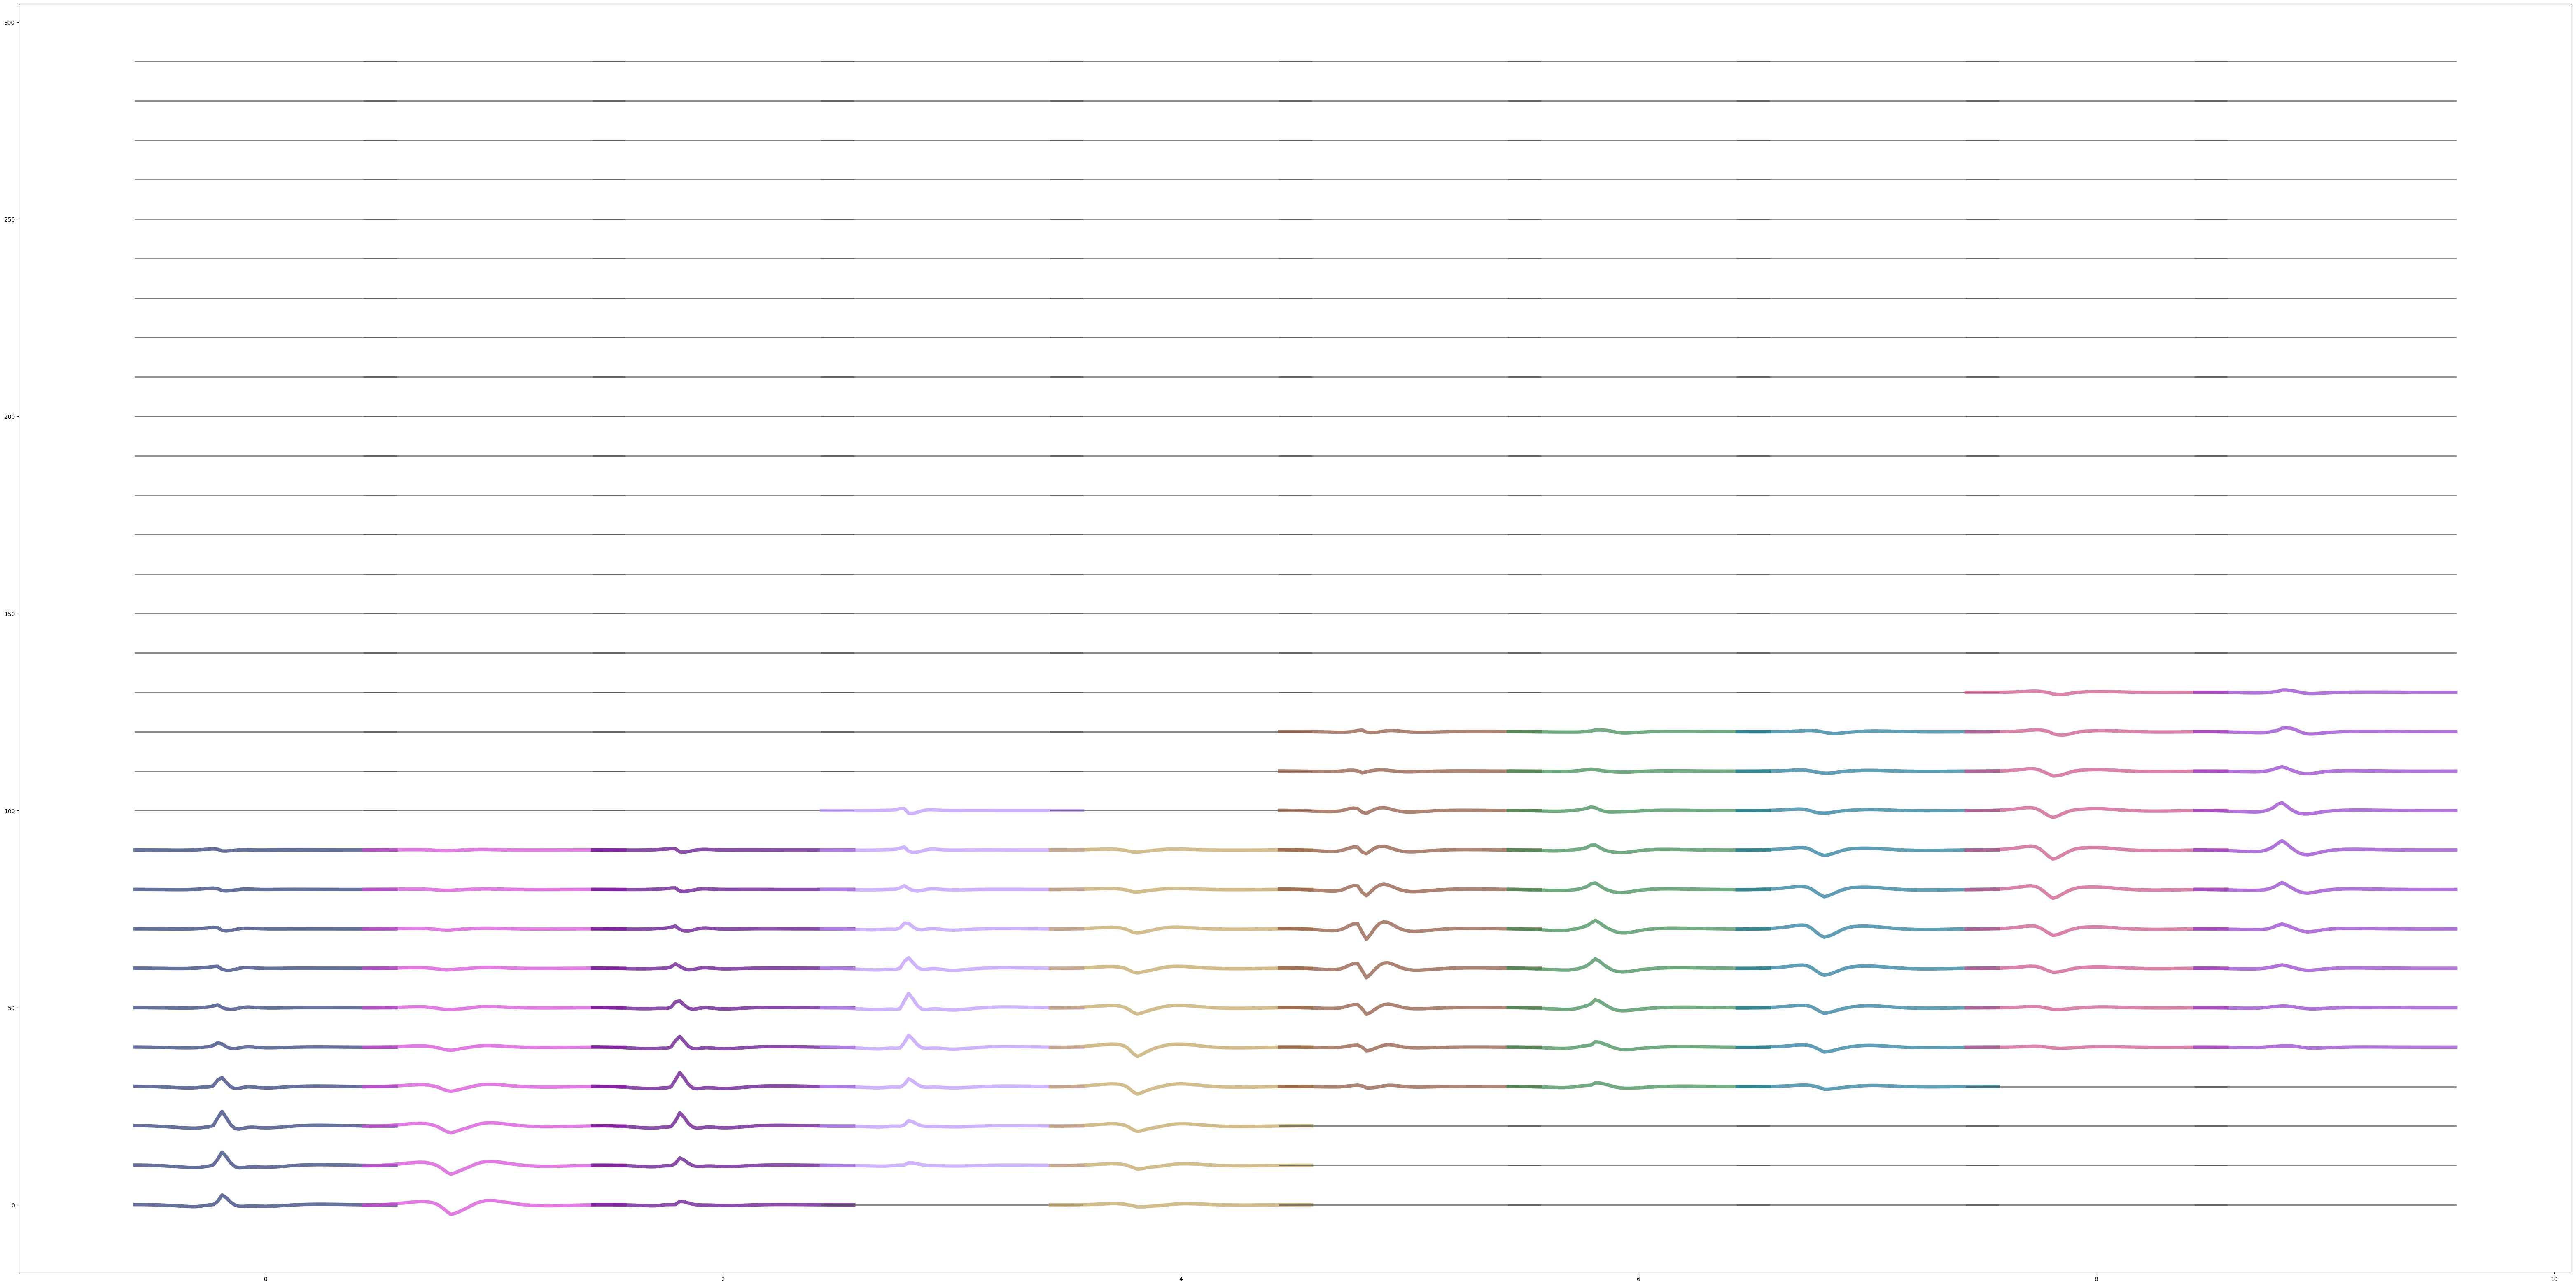

In [10]:
import numpy as np
import matplotlib.pyplot as plt

sorted_channel_indices = np.argsort(channel_y_positions)
ch_idx = sorted_channel_indices[np.arange(0,30)]
unit_idx = np.arange(0,10)
channel_y_positions = channel_positions[:, 1]
plt.figure(figsize=(80, 40))
x_id = 0
for unit_id in unit_idx:
    random_color = np.random.rand(3,)
#     if np.mean(templates[unit_id, :, ch_idx]) > 0:
    
    for ch_id in ch_idx:
        waveform = []
        waveform = templates[unit_id, :, ch_id]
        if np.abs(waveform).max() > 0.1:
            colorp = random_color
            width=6
        else:
            colorp = [0.3, 0.3, 0.3]
            width=2

#             print(unit_id, ch_id)
#             print(channel_y_positions[ch_id])
        waveform = waveform + channel_y_positions[ch_id] /2
        x_pos = np.linspace(-1.9, 1.9, 61)*0.3 + x_id 
        plt.plot(x_pos, waveform, color=colorp, linewidth=width, alpha=0.7)
    x_id += 1


# plt.xlabel("Unit Index")
# plt.ylabel("Amplitude")
# plt.title(f"Waveforms of All Units at Channel {ch_idx}")
plt.grid(False)
plt.savefig(r"\\172.30.3.33\homes\fetschlab\labMembers\Yueh-Chen\templates.png")
plt.show()

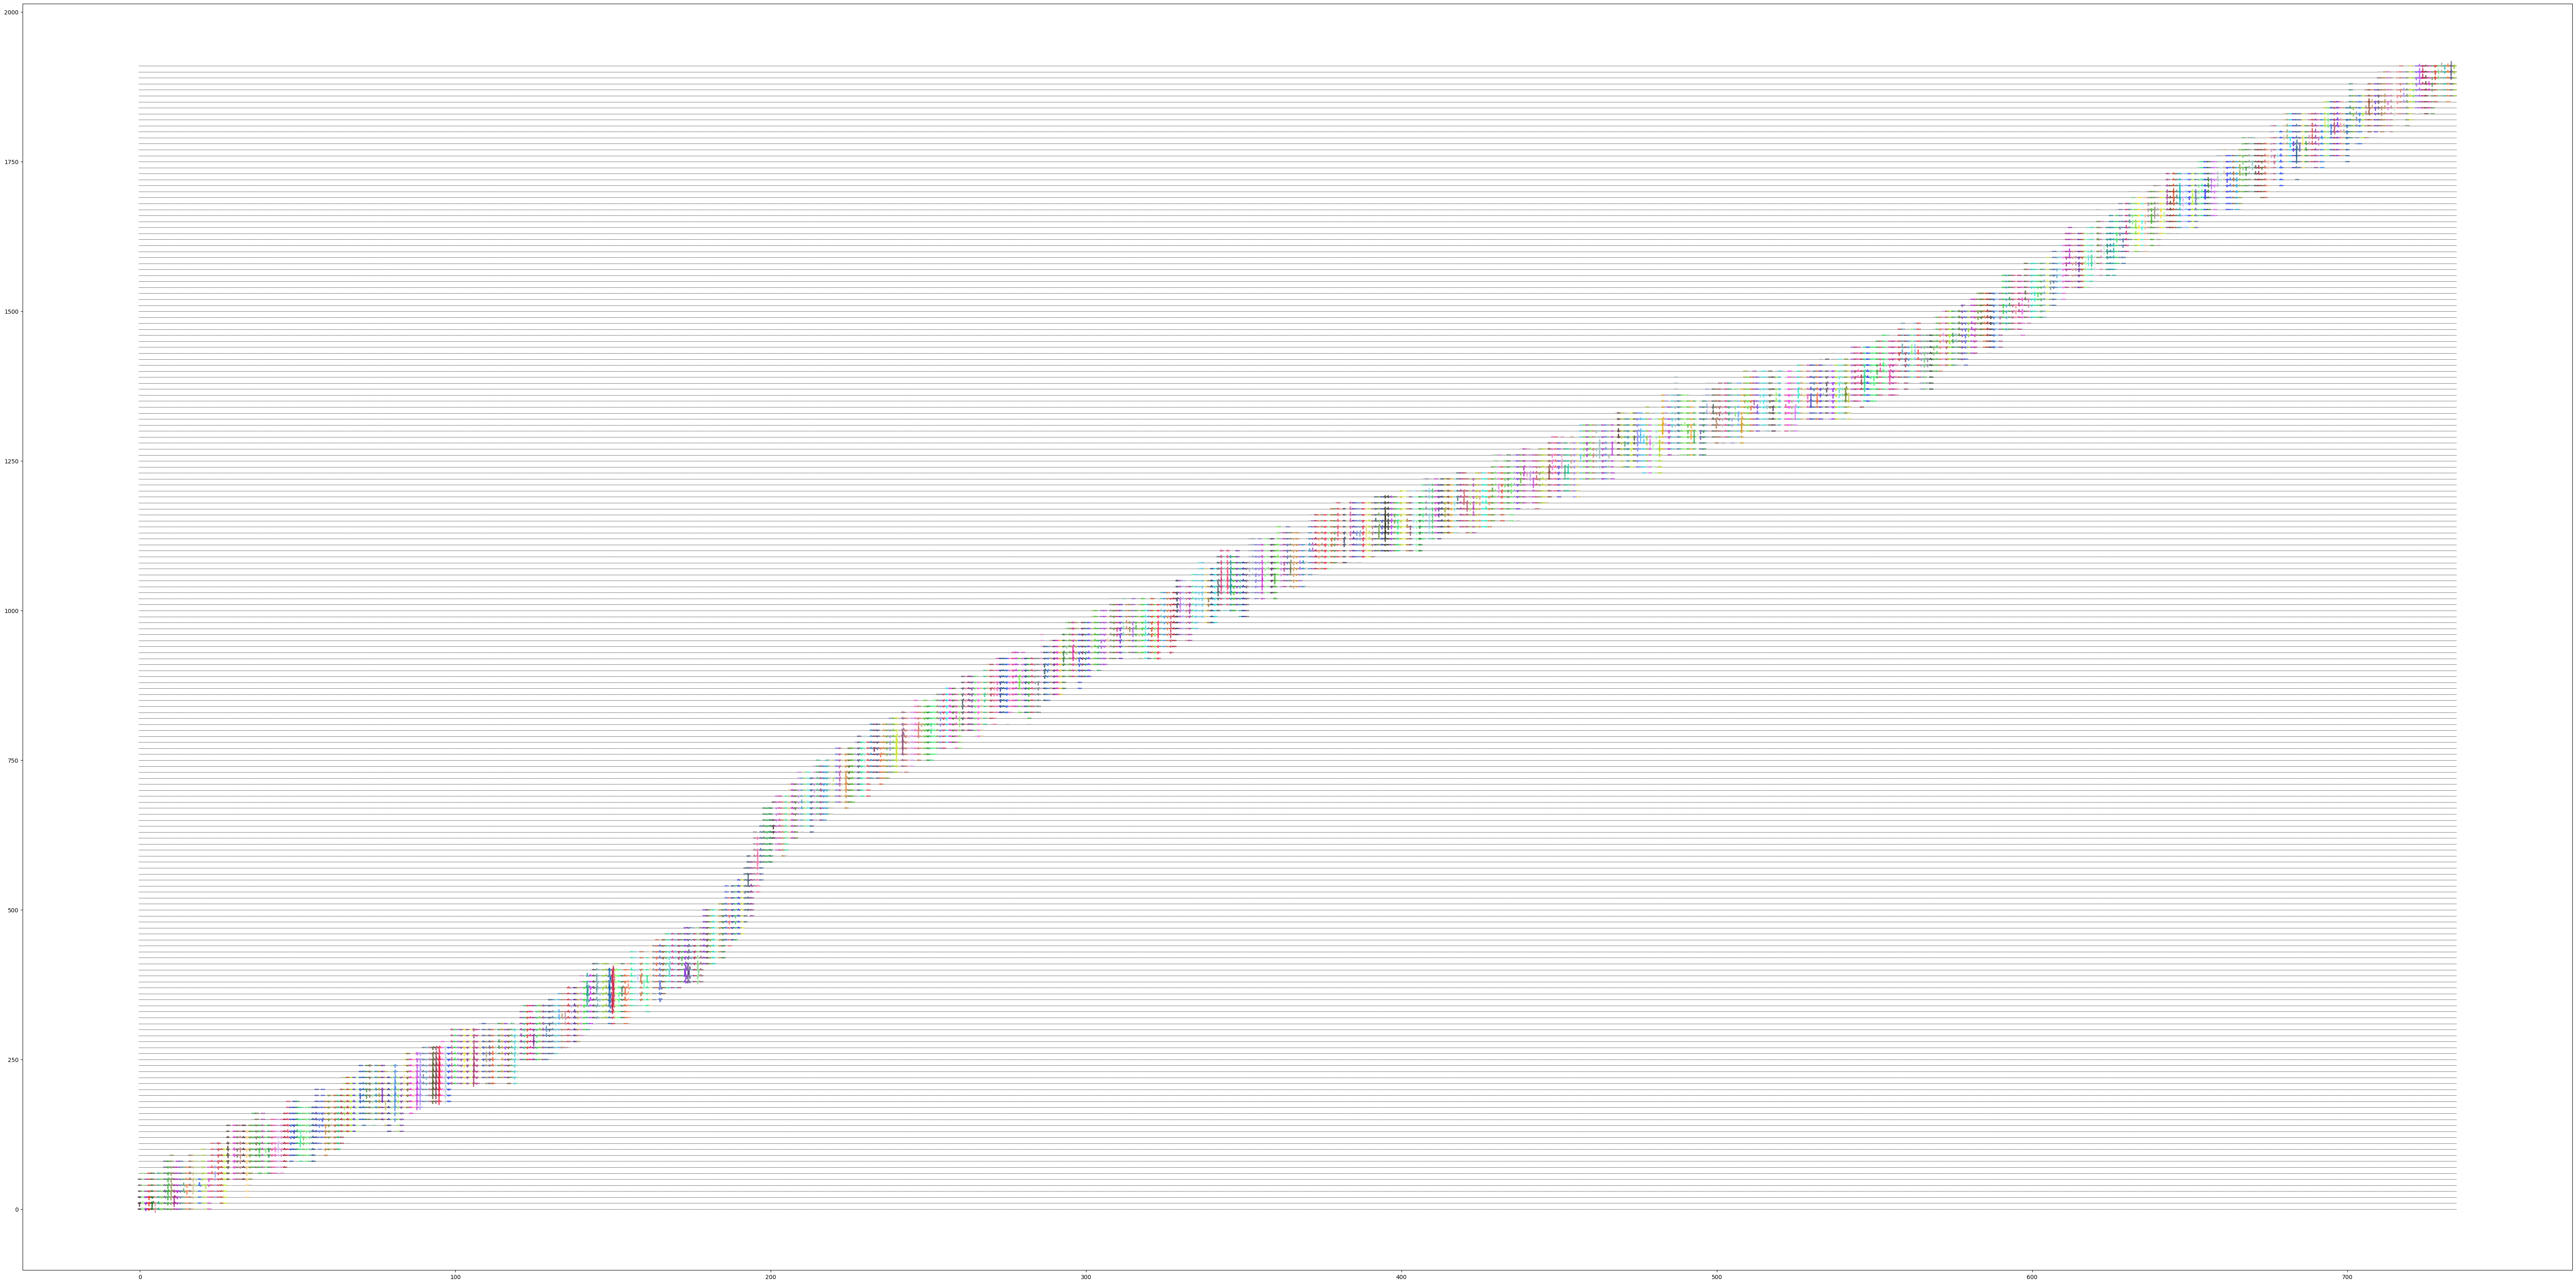

In [60]:
import numpy as np
import matplotlib.pyplot as plt

#  `templates` is  (735, 61, 384) matrix
ch_idx = range(384)
unit_idx = range(735)
channel_y_positions = channel_positions[:, 1]
plt.figure(figsize=(80, 40))

for unit_id in unit_idx:
    random_color = np.random.rand(3,)
    
    for ch_id in ch_idx:
        waveform = []
        waveform = templates[unit_id, :, ch_id]
        if np.abs(waveform).max() > 0.1:
            colorp = random_color
            width=2
        else:
            colorp = [0.3, 0.3, 0.3]
            width=0.5
                
            
        waveform = waveform + channel_y_positions[ch_id] /2
        x_pos = np.linspace(-0.5, 0.5, 61) + unit_id  
        plt.plot(x_pos, waveform, color=colorp, linewidth=width, alpha=0.7)



# plt.xlabel("Unit Index")
# plt.ylabel("Amplitude")
# plt.title(f"Waveforms of All Units at Channel {ch_idx}")
plt.grid(False)
plt.savefig(r"\\172.30.3.33\homes\fetschlab\labMembers\Yueh-Chen\templates_all.png")
plt.show()

✓ Loaded cluster_KSLabel.tsv (KiloSort labels)
✓ Loaded cluster_group.tsv (curated labels)
✓ Loaded cluster_info.tsv

Choose label type:
1. Curated labels (cluster_group.tsv)
2. KiloSort labels (cluster_KSLabel.tsv)
Using curated labels (cluster_group.tsv)

Found 125 good units using curated labels

Waveform classification:
Negative spiking: 79 (63.2%)
Unknown/Mixed: 2 (1.6%)


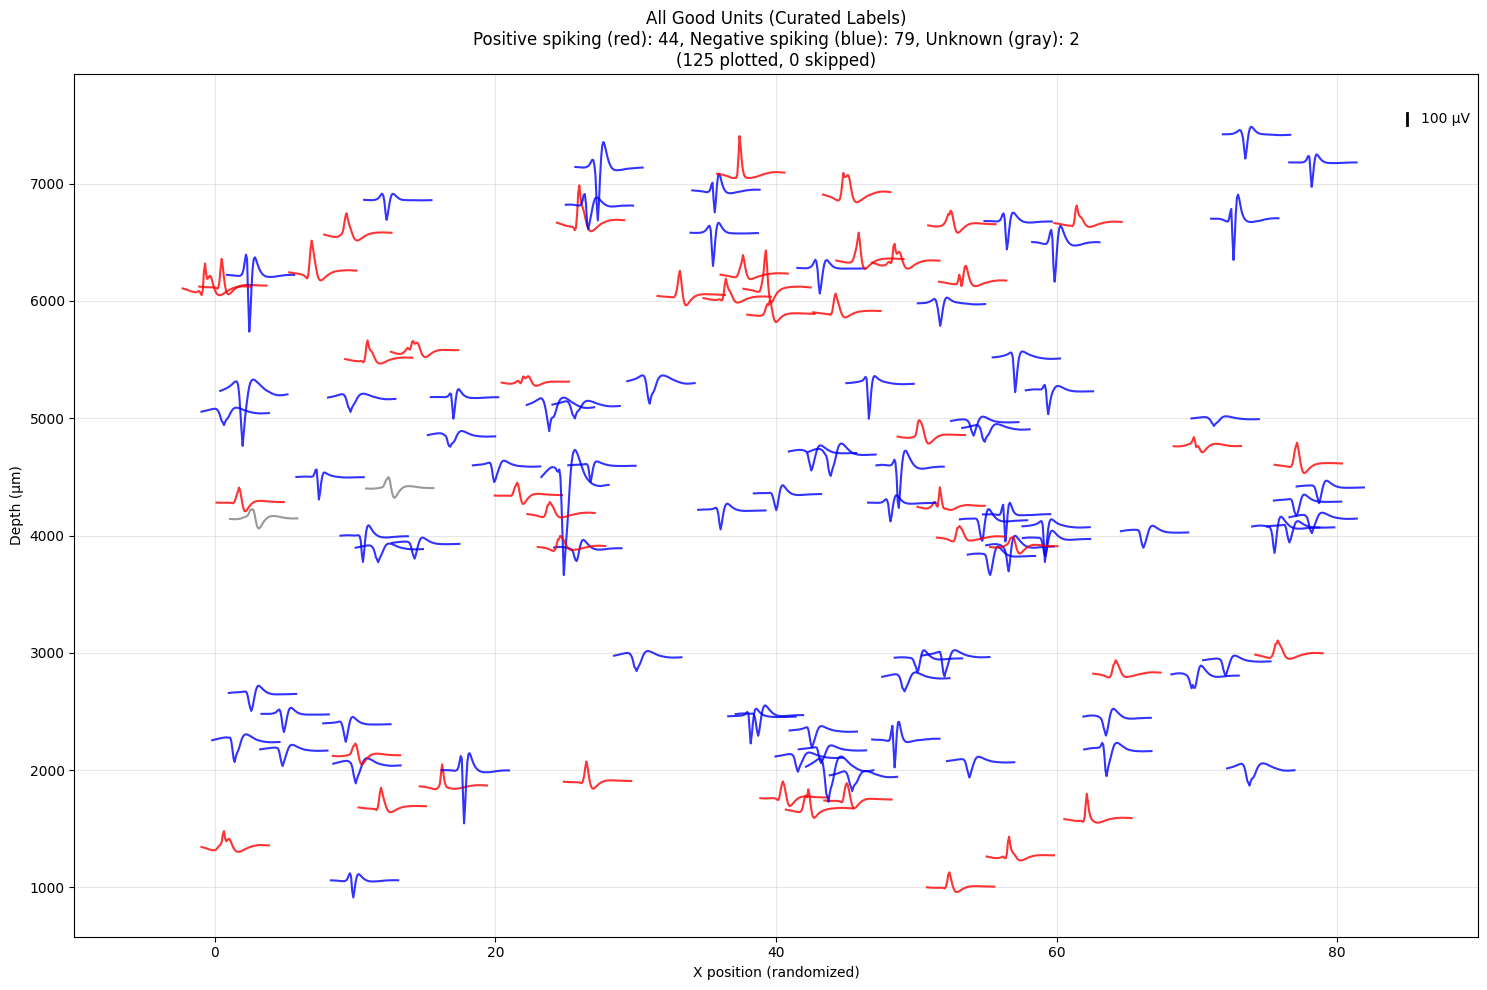

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
def load_data(phy_dir):
    phy_dir = Path(phy_dir)
    files = {
        'spike_clusters': 'spike_clusters.npy',
        'spike_times': 'spike_times.npy',
        'templates': 'templates.npy',
        'channel_positions': 'channel_positions.npy',
        'amplitudes': 'amplitudes.npy'
    }
    data = {k: np.load(phy_dir / f) for k, f in files.items()}
    
    # Load both KiloSort labels and curated labels
    try:
        data['cluster_KSLabel'] = pd.read_csv(phy_dir / 'cluster_KSLabel.tsv', sep='\t')
        print("✓ Loaded cluster_KSLabel.tsv (KiloSort labels)")
    except:
        print("✗ Could not find cluster_KSLabel.tsv")
        data['cluster_KSLabel'] = None
    
    try:
        data['cluster_group'] = pd.read_csv(phy_dir / 'cluster_group.tsv', sep='\t')
        print("✓ Loaded cluster_group.tsv (curated labels)")
    except:
        print("✗ Could not find cluster_group.tsv")
        data['cluster_group'] = None
    
    # Load cluster_info.tsv which contains depth information
    try:
        data['cluster_info'] = pd.read_csv(phy_dir / 'cluster_info.tsv', sep='\t')
        print("✓ Loaded cluster_info.tsv")
    except:
        print("✗ Could not find cluster_info.tsv")
        data['cluster_info'] = None
    
    try:
        data['spike_templates'] = np.load(phy_dir / 'spike_templates.npy')
    except:
        data['spike_templates'] = None
    
    return data

# Get good units based on label type
def get_good_units(data, use_curated=True):
    """
    Get good units based on either curated labels or KiloSort labels
    
    Parameters:
    -----------
    data : dict
        Data dictionary containing cluster labels
    use_curated : bool
        If True, use curated labels (cluster_group.tsv)
        If False, use KiloSort labels (cluster_KSLabel.tsv)
    
    Returns:
    --------
    array : cluster IDs of good units
    """
    if use_curated:
        if data['cluster_group'] is None:
            print("Warning: No curated labels found. Falling back to KiloSort labels.")
            return get_good_units(data, use_curated=False)
        
        cluster_df = data['cluster_group']
        label_column = 'group'
        print("Using curated labels (cluster_group.tsv)")
    else:
        if data['cluster_KSLabel'] is None:
            raise ValueError("No KiloSort labels found!")
        
        cluster_df = data['cluster_KSLabel']
        label_column = 'KSLabel'
        print("Using KiloSort labels (cluster_KSLabel.tsv)")
    
    good_units = cluster_df[cluster_df[label_column] == 'good']['cluster_id'].values
    return good_units

# Get unit depth from cluster_info
def get_unit_depth(unit_id, cluster_info):
    """Get depth for a specific unit from cluster_info"""
    if cluster_info is None:
        return None
    
    unit_row = cluster_info[cluster_info['cluster_id'] == unit_id]
    if len(unit_row) == 0:
        return None
    
    # Try different possible column names for depth
    depth_columns = ['depth', 'Depth', 'depth_um', 'depth_µm']
    for col in depth_columns:
        if col in unit_row.columns:
            return unit_row[col].values[0]
    
    return None

# Classify waveform based on amplitude and timing
def classify_waveform(waveform):
    """
    Classify waveform as positive or negative based on:
    - If negative peak happens before positive peak -> negative waveform
    - If positive peak happens first AND peak-trough-ratio < 1 -> positive waveform
    - Otherwise -> gray/unknown
    
    Peak-trough-ratio = positive peak / |negative peak|
    """
    max_val = np.max(waveform)
    min_val = np.min(waveform)
    max_idx = np.argmax(waveform)
    min_idx = np.argmin(waveform)
    
    # Calculate peak-trough ratio (positive peak / |negative peak|)
    if min_val != 0:
        peak_trough_ratio = max_val / min_val
    else:
        peak_trough_ratio = float('inf') if max_val > 0 else 0
    
    # Apply classification criteria
    # if min_idx < max_idx:
    if peak_trough_ratio > -1:
        # Negative peak happens before positive peak -> negative waveform
        return 'negative'
    elif peak_trough_ratio < -1.5:
        # Positive peak happens first AND peak-trough-ratio < 1 -> positive waveform
        return 'positive'
    else:
        return 'unknown'

# Compute unit waveform with better quality
def compute_unit_waveform(unit_id, templates):
    template = templates[unit_id]
    
    # Find the channel with maximum amplitude
    peak_amplitudes = np.max(np.abs(template), axis=0)
    max_channel = np.argmax(peak_amplitudes)
    
    # Get a few channels around the max for better waveform shape
    n_channels = template.shape[1]
    start_ch = max(0, max_channel - 5)
    end_ch = min(n_channels, max_channel + 6)
    
    # Average across these few channels
    waveform = np.mean(template[:, start_ch:end_ch], axis=1)
    
    return waveform

# Compute unit waveform from spikes for merged/split units
def compute_unit_waveform_from_spikes(unit_id, data, max_spikes=500):
    unit_spikes = np.where(data['spike_clusters'] == unit_id)[0]
    
    if len(unit_spikes) == 0:
        return None
    
    if len(unit_spikes) > max_spikes:
        unit_spikes = np.random.choice(unit_spikes, max_spikes, replace=False)
    
    if data['spike_templates'] is not None:
        template_ids = data['spike_templates'][unit_spikes]
    else:
        template_ids = data['spike_clusters'][unit_spikes]
    
    templates_list = []
    for tid in template_ids:
        if tid < len(data['templates']):
            templates_list.append(data['templates'][tid])
    
    if len(templates_list) == 0:
        return None
    
    # Average the templates
    mean_template = np.mean(templates_list, axis=0)
    
    # Find max channel and use nearby channels
    peak_amplitudes = np.max(np.abs(mean_template), axis=0)
    max_channel = np.argmax(peak_amplitudes)
    
    n_channels = mean_template.shape[1]
    start_ch = max(0, max_channel - 2)
    end_ch = min(n_channels, max_channel + 3)
    
    waveform = np.mean(mean_template[:, start_ch:end_ch], axis=1)
    
    return waveform

# Main plotting function
def plot_all_units(data, good_units, label_type='curated'):
    fig, ax = plt.subplots(figsize=(15, 10))
    
    skipped_units = []
    plotted_units = []
    positive_count = 0
    negative_count = 0
    unknown_count = 0
    
    # Set random seed for reproducibility
    np.random.seed(42)
    
    for unit_id in good_units:
        # Get depth from cluster_info
        depth = get_unit_depth(unit_id, data['cluster_info'])
        if depth is None:
            print(f"Warning: No depth info for unit {unit_id}")
            skipped_units.append(unit_id)
            continue
        
        # Get waveform
        waveform = compute_unit_waveform_from_spikes(unit_id, data)
            
        if waveform is None:
            skipped_units.append(unit_id)
            continue
        
        plotted_units.append(unit_id)
        
        # Baseline correction
        waveform = waveform - np.mean(waveform[:5])
        
        # Classify based on amplitude and timing
        waveform_type = classify_waveform(waveform)
        color = 'red' if waveform_type == 'positive' else 'blue' if waveform_type == 'negative' else 'gray'
        
        if waveform_type == 'positive':
            positive_count += 1
        elif waveform_type == 'negative':
            negative_count += 1
        else:
            unknown_count += 1
        
        # Randomize x position
        random_x = np.random.uniform(0, 80)
        
        # Scale waveform
        # Create time axis - assuming ~1-2ms waveform
        n_samples = len(waveform)
        time_ms = np.linspace(-0.3, 0.3, n_samples)
        
        # Scale amplitude for visualization
        # Typical spike amplitudes are 50-200 μV
        waveform_scaled = waveform * 100
        
        # Plot at randomized x position, use depth from cluster_info
        ax.plot(random_x + time_ms * 8,  # Spread waveforms horizontally
               depth + waveform_scaled, 
               color=color, linewidth=1.5, alpha=0.8)
    
    ax.set_xlabel('X position (randomized)')
    ax.set_ylabel('Depth (μm)')
    ax.set_title(f'All Good Units ({label_type.capitalize()} Labels)\n' + 
                f'Positive spiking (red): {positive_count}, Negative spiking (blue): {negative_count}, Unknown (gray): {unknown_count}\n' +
                f'({len(plotted_units)} plotted, {len(skipped_units)} skipped)')
    ax.grid(True, alpha=0.3)
    
    # Set x-axis limits
    ax.set_xlim(-10, 90)
    
    if skipped_units:
        print(f"Skipped units (no waveform/depth data): {skipped_units}")
    
    print(f"\nWaveform classification:")
    # print(f"Positive spiking: {positive_count} ({positive_count/len(plotted_units)*100:.1f}%)")
    print(f"Negative spiking: {negative_count} ({negative_count/len(plotted_units)*100:.1f}%)")
    print(f"Unknown/Mixed: {unknown_count} ({unknown_count/len(plotted_units)*100:.1f}%)")
    
    # Add a scale bar for reference
    ax.plot([85, 85], [7500, 7600], 'k-', linewidth=2)
    ax.text(86, 7550, '100 μV', fontsize=10, va='center')
    
    plt.tight_layout()
    plt.show()

# Main execution with user choice
if __name__ == "__main__":
    # Set your data directory
    phy_dir = r'D:\Neural-Pipeline\data\20250602\kilosort4_phy'
    
    # Load data
    data = load_data(phy_dir)
    
    # Choose which labels to use
    print("\nChoose label type:")
    print("1. Curated labels (cluster_group.tsv)")
    print("2. KiloSort labels (cluster_KSLabel.tsv)")
    
    choice = input("Enter your choice (1 or 2): ").strip()
    
    if choice == '1':
        use_curated = True
        label_type = 'curated'
    elif choice == '2':
        use_curated = False
        label_type = 'kilosort'
    else:
        print("Invalid choice. Using curated labels by default.")
        use_curated = True
        label_type = 'curated'
    
    # Get good units based on choice
    good_units = get_good_units(data, use_curated=use_curated)
    print(f"\nFound {len(good_units)} good units using {label_type} labels")
    
    # Plot
    plot_all_units(data, good_units, label_type=label_type)

✓ Loaded cluster_KSLabel.tsv (KiloSort labels)
✓ Loaded cluster_group.tsv (curated labels)
✓ Loaded cluster_info.tsv
✓ Loaded cluster_WaveMAP.csv
  Columns: ['cluster_id', 'wavemap_cluster', 'waveform']

Choose label type:
1. Curated labels (cluster_group.tsv)
2. KiloSort labels (cluster_KSLabel.tsv)
Using curated labels (cluster_group.tsv)

Found 275 good units using curated labels

Waveform classification:
Positive spiking (blue): 126
Negative spiking (red): 149
Unknown/Missing (gray): 0
Total plotted: 275, Skipped: 0


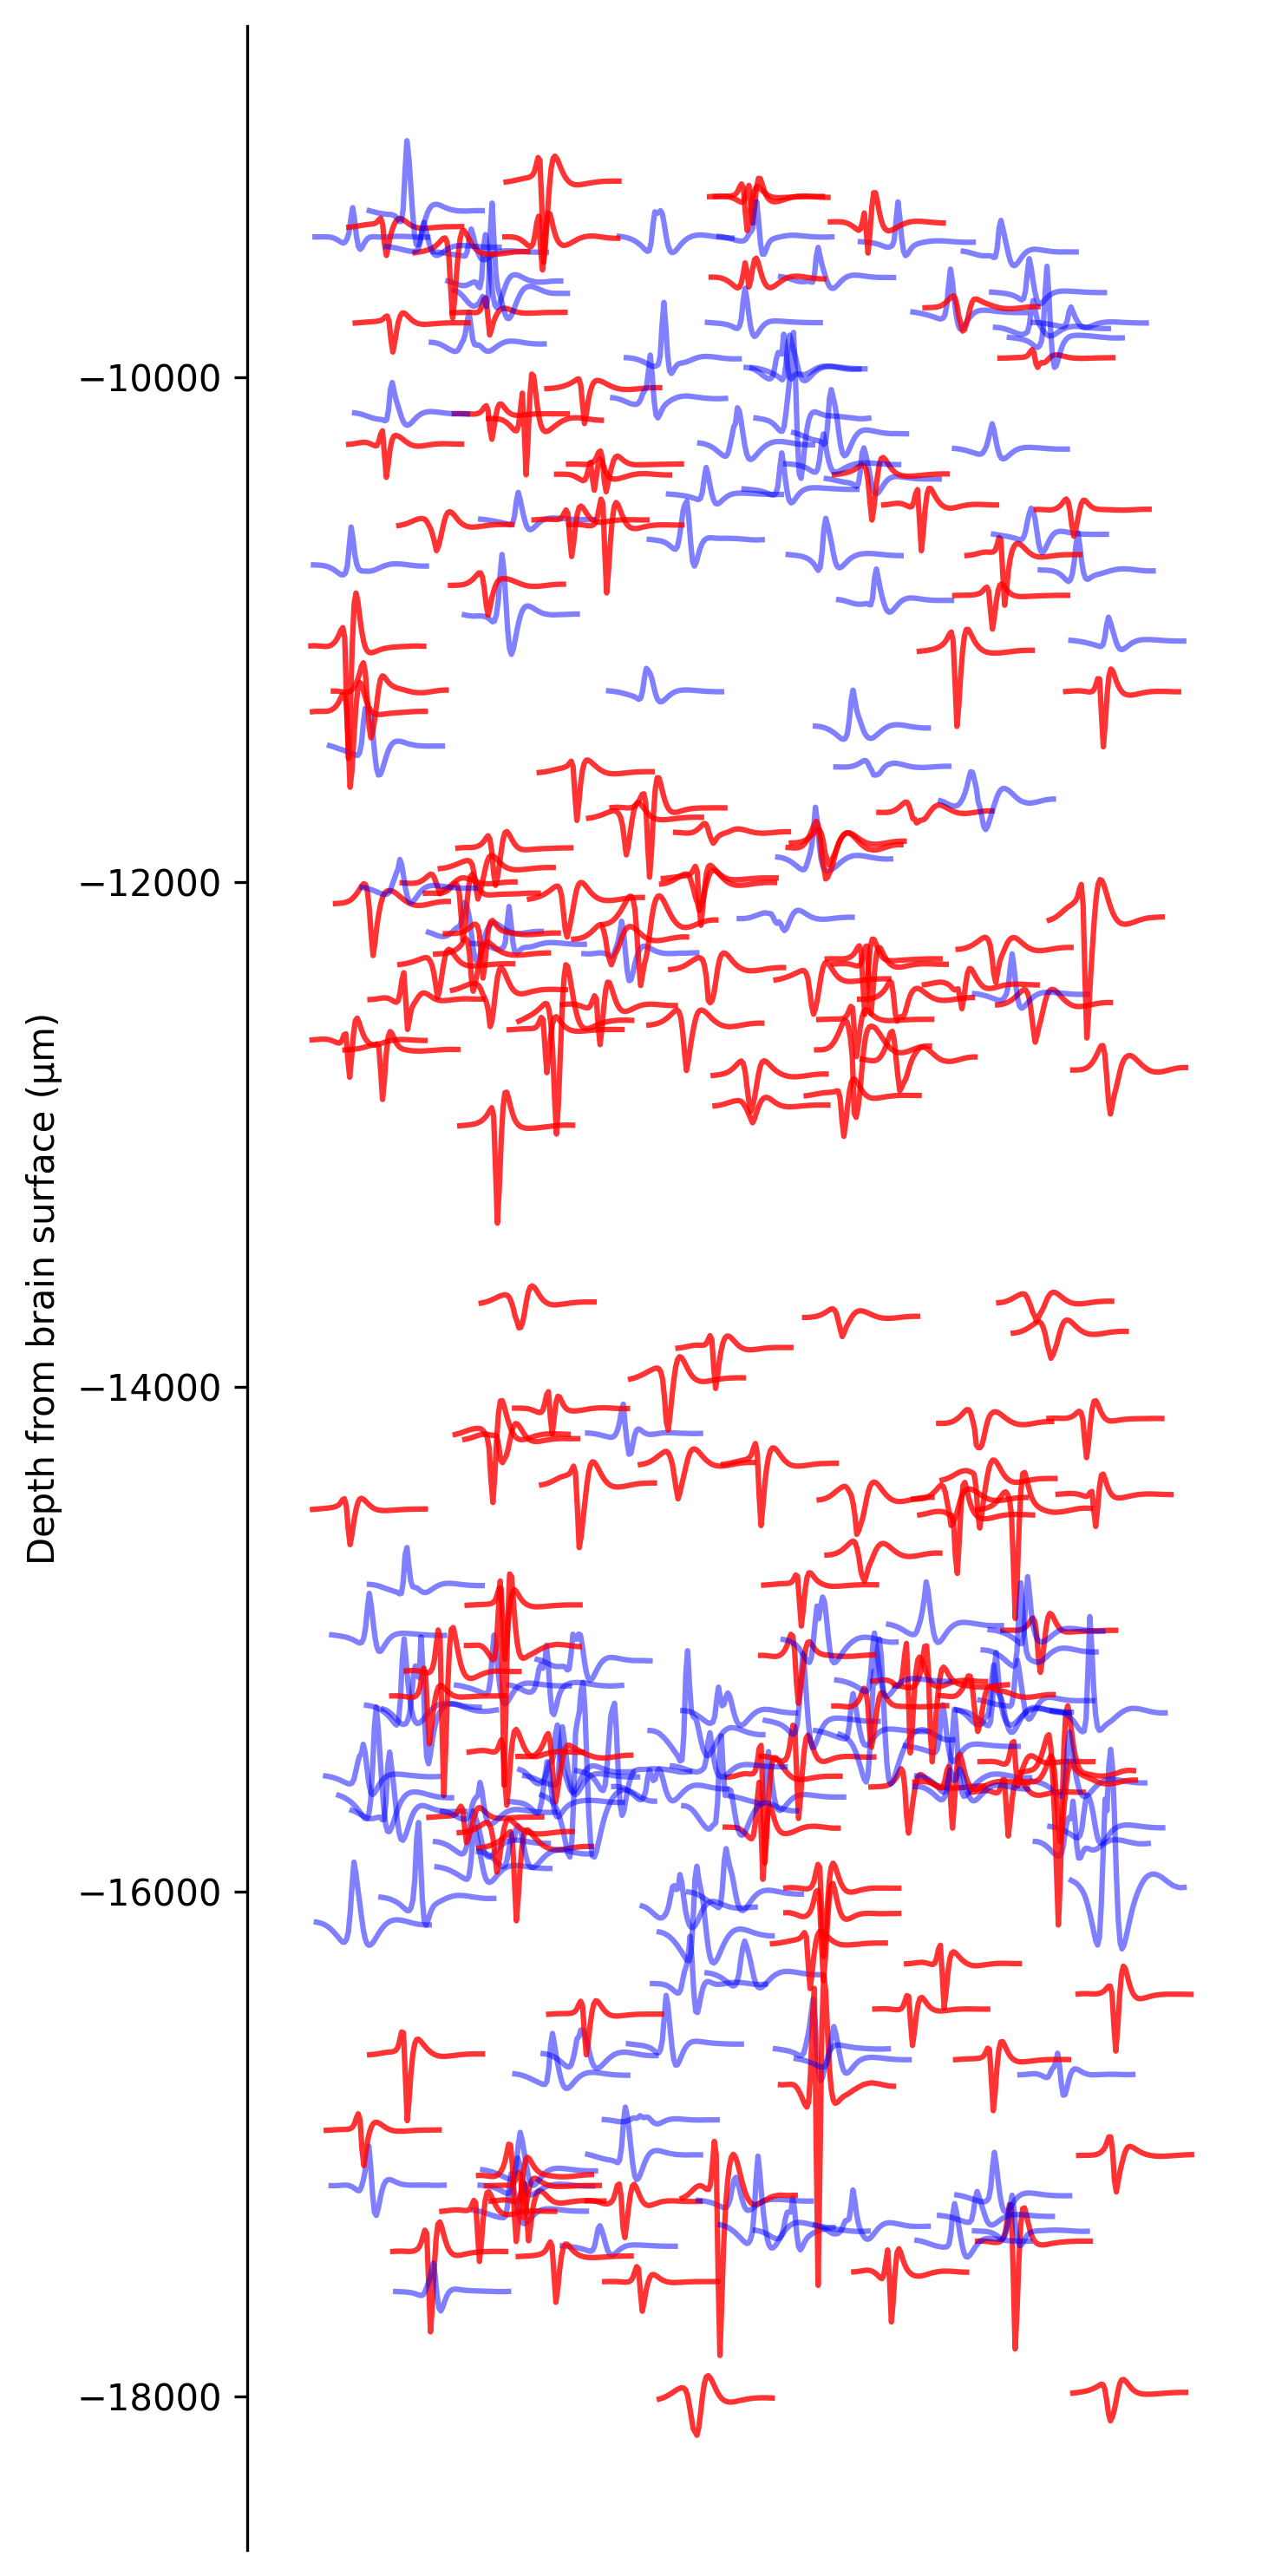

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
def load_data(phy_dir):
    phy_dir = Path(phy_dir)
    files = {
        'spike_clusters': 'spike_clusters.npy',
        'spike_times': 'spike_times.npy',
        'templates': 'templates.npy',
        'channel_positions': 'channel_positions.npy',
        'amplitudes': 'amplitudes.npy'
    }
    data = {k: np.load(phy_dir / f) for k, f in files.items()}

    try:
        data['cluster_KSLabel'] = pd.read_csv(phy_dir / 'cluster_KSLabel.tsv', sep='\t')
        print("✓ Loaded cluster_KSLabel.tsv (KiloSort labels)")
    except:
        print("✗ Could not find cluster_KSLabel.tsv")
        data['cluster_KSLabel'] = None

    try:
        data['cluster_group'] = pd.read_csv(phy_dir / 'cluster_group.tsv', sep='\t')
        print("✓ Loaded cluster_group.tsv (curated labels)")
    except:
        print("✗ Could not find cluster_group.tsv")
        data['cluster_group'] = None

    try:
        data['cluster_info'] = pd.read_csv(phy_dir / 'cluster_info.tsv', sep='\t')
        print("✓ Loaded cluster_info.tsv")
    except:
        print("✗ Could not find cluster_info.tsv")
        data['cluster_info'] = None

    try:
        data['spike_templates'] = np.load(phy_dir / 'spike_templates.npy')
    except:
        data['spike_templates'] = None
    
    try:
        data['cluster_wavemap'] = pd.read_csv(phy_dir / 'cluster_WaveMAP.csv')
        print("✓ Loaded cluster_WaveMAP.csv")
        print(f"  Columns: {data['cluster_wavemap'].columns.tolist()}")
    except:
        print("✗ Could not find cluster_WaveMAP.csv")
        data['cluster_wavemap'] = None

    return data

# Get good units based on label type
def get_good_units(data, use_curated=True):
    if use_curated:
        if data['cluster_group'] is None:
            print("Warning: No curated labels found. Falling back to KiloSort labels.")
            return get_good_units(data, use_curated=False)

        cluster_df = data['cluster_group']
        label_column = 'group'
        print("Using curated labels (cluster_group.tsv)")
    else:
        if data['cluster_KSLabel'] is None:
            raise ValueError("No KiloSort labels found!")

        cluster_df = data['cluster_KSLabel']
        label_column = 'KSLabel'
        print("Using KiloSort labels (cluster_KSLabel.tsv)")

    good_units = cluster_df[cluster_df[label_column] == 'good']['cluster_id'].values
    return good_units

# Get unit depth from cluster_info
def get_unit_depth(unit_id, cluster_info):
    if cluster_info is None:
        return None

    unit_row = cluster_info[cluster_info['cluster_id'] == unit_id]
    if len(unit_row) == 0:
        return None

    depth_columns = ['depth', 'Depth', 'depth_um', 'depth_µm']
    for col in depth_columns:
        if col in unit_row.columns:
            return unit_row[col].values[0]

    return None

# Get waveform type for a unit from cluster_WaveMAP.csv
def get_unit_waveform_type(unit_id, cluster_wavemap):
    if cluster_wavemap is None:
        return None
    
    # Look for the unit in cluster_id column
    unit_row = cluster_wavemap[cluster_wavemap['cluster_id'] == unit_id]
    
    if len(unit_row) == 0:
        return None
    
    # Get the waveform type (positive or negative)
    waveform_type = unit_row['waveform'].values[0]
    
    return waveform_type

# Compute unit waveform from spikes for curated units
def compute_unit_waveform_from_spikes(unit_id, data, max_spikes=500):
    unit_spikes = np.where(data['spike_clusters'] == unit_id)[0]
    
    if len(unit_spikes) == 0:
        return None
    
    if len(unit_spikes) > max_spikes:
        unit_spikes = np.random.choice(unit_spikes, max_spikes, replace=False)
    
    if data['spike_templates'] is not None:
        template_ids = data['spike_templates'][unit_spikes]
    else:
        template_ids = data['spike_clusters'][unit_spikes]
    
    templates_dict = {}

    # Step 1: Collect waveforms and counts
    for tid in template_ids:
        if tid < len(data['templates']):
            if tid not in templates_dict:
                templates_dict[tid] = {'count': 0, 'template': data['templates'][tid]}
            templates_dict[tid]['count'] += 1

    if len(templates_dict) == 0:
        return None
    
    # Step 2: Get template shape
    num_time_points = data['templates'][0].shape[0]
    num_channels = data['templates'][0].shape[1]
    
    # Step 3: Compute weighted waveform across all channels
    weighted_waveform = np.zeros((num_time_points, num_channels))
    total_count = 0

    for tid, tmpl_info in templates_dict.items():
        count = tmpl_info['count']
        template = tmpl_info['template']  # shape (num_time_points, num_channels)
        
        # Add weighted contribution
        weighted_waveform += template * count
        total_count += count

    # Step 4: Normalize by total count
    weighted_waveform /= total_count if total_count > 0 else 1
    
    # Step 5: Find the max channel across all time points
    peak_amplitudes = np.max(np.abs(weighted_waveform), axis=0)  # shape (num_channels,)
    max_channel = np.argmax(peak_amplitudes)
    
    # Step 6: Average around the max channel to compute the final waveform
    start_ch = max(0, max_channel - 2)
    end_ch = min(num_channels, max_channel + 3)
    
    final_waveform = np.mean(weighted_waveform[:, start_ch:end_ch], axis=1)  # shape (num_time_points,)
    
    return final_waveform

# Main plotting function
def plot_all_units(data, good_units, label_type='curated', probe_depth=16745, guide_tube_adj=2000):
    fig, ax = plt.subplots(figsize=(5, 10), dpi=300)

    color_map = {
        'positive': 'blue',
        'negative': 'red',
        'unknown': 'gray'
    }
    alpha_map = {
        'positive': 0.5,   
        'negative': 0.8,
        'unknown': 0.5
    }

    skipped_units = []
    plotted_units = []
    counts = {'positive': 0, 'negative': 0, 'unknown': 0}

    np.random.seed(81)
    
    # Number of units for scaling
    num_units = len(good_units)
    
    for unit_id in good_units:
        depth = get_unit_depth(unit_id, data['cluster_info'])
        if depth is None:
            print(f"Warning: No depth info for unit {unit_id}")
            skipped_units.append(unit_id)
            continue

        waveform = compute_unit_waveform_from_spikes(unit_id, data)
        
        if waveform is None:
            skipped_units.append(unit_id)
            continue

        plotted_units.append(unit_id)

        # Baseline correction
        waveform = waveform - np.mean(waveform[:5])
        
        # Get waveform type from cluster_WaveMAP.csv
        waveform_type = get_unit_waveform_type(unit_id, data['cluster_wavemap'])
        
        if waveform_type is not None:
            # Convert to lowercase to match color_map keys
            waveform_type = waveform_type.lower().strip()
            color = color_map.get(waveform_type, 'gray')
            alpha = alpha_map.get(waveform_type, 0.7)
            if waveform_type in counts:
                counts[waveform_type] += 1
            else:
                counts['unknown'] += 1
        else:
            color = 'gray'
            counts['unknown'] += 1

        # Calculate depth from brain surface
        depth_from_surface = depth - probe_depth - guide_tube_adj

        # Randomly distribute X position within range proportional to number of units
        x_range = num_units / 5  # This gives ±25 for 125 units
        random_x = np.random.uniform(-x_range, x_range)

        # Plot the waveform
        n_samples = len(waveform)
        time_ms = np.linspace(-1, 1, n_samples)
        
        ax.plot(random_x + time_ms * 8, depth_from_surface + (waveform * 100), color=color, linewidth=1.5, alpha=alpha)

    # Remove x-axis
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Keep only left y-axis at its default position
    ax.spines['left'].set_position(('outward', 0))
    
    ax.set_ylabel('Depth from brain surface (μm)')
    
    # Set x-axis limits based on x_range + waveform width
    waveform_width = 2.0 * 8  # 2.0ms total span * 8 scaling factor = 16
    x_limit = x_range + waveform_width
    ax.set_xlim(-x_limit, x_limit)

    if skipped_units:
        print(f"Skipped units (no waveform/depth data): {skipped_units}")

    print("\nWaveform classification:")
    print(f"Positive spiking (blue): {counts['positive']}")
    print(f"Negative spiking (red): {counts['negative']}")
    print(f"Unknown/Missing (gray): {counts['unknown']}")
    print(f"Total plotted: {len(plotted_units)}, Skipped: {len(skipped_units)}")

    plt.tight_layout()
    plt.show()

# Main execution with user choice
if __name__ == "__main__":
    phy_dir = r'D:\Neural-Pipeline\data\20250306\kilosort4_phy'
    
    # Load data
    data = load_data(phy_dir)

    print("\nChoose label type:")
    print("1. Curated labels (cluster_group.tsv)")
    print("2. KiloSort labels (cluster_KSLabel.tsv)")

    choice = input("Enter your choice (1 or 2): ").strip()

    if choice == '1':
        use_curated = True
        label_type = 'curated'
    elif choice == '2':
        use_curated = False
        label_type = 'kilosort'
    else:
        print("Invalid choice. Using curated labels by default.")
        use_curated = True
        label_type = 'curated'

    good_units = get_good_units(data, use_curated=use_curated)
    print(f"\nFound {len(good_units)} good units using {label_type} labels")

    plot_all_units(data, good_units, label_type=label_type, probe_depth=16745, guide_tube_adj=2000)

In [22]:
import numpy as np
cluster = np.load(r"D:\Neural-Pipeline\data\20250306\kilosort4_phy\spike_clusters.npy")
templates_id = np.load(r"D:\Neural-Pipeline\data\20250306\kilosort4_phy\spike_detection_templates.npy")
waveforms = np.load(r"D:\Neural-Pipeline\data\20250306\kilosort4_phy\templates.npy")
print(waveforms.shape)

(972, 61, 384)
